#### Imports

In [1]:
%pip install --break-system-packages google-cloud-bigquery pandas numpy scikit-learn matplotlib seaborn --quiet
%pip install google-cloud-bigquery

#### Authenticate on Google

In [2]:
from google.colab import auth
auth.authenticate_user()
print('Authenticated')

Authenticated


#### Access BigQuery

In [3]:
from google.cloud import bigquery
project_id = 'ai-on-healthcare'
client = bigquery.Client(project=project_id)

#### Querying women from the dataset


In [4]:
query = """
SELECT
  p.subject_id,
  p.gender,
  p.dob,
  a.hadm_id,
  a.admittime,
  a.dischtime,
  a.admission_type,
  a.insurance,
  a.language,
  a.religion,
  a.marital_status,
  a.hospital_expire_flag AS mortality,
  a.ethnicity,
  COUNT(DISTINCT ie.icustay_id) AS num_icu_stays,
  COUNT(DISTINCT di.icd9_code) AS num_diagnoses,
  STRING_AGG(DISTINCT di.icd9_code, ', ') AS diagnose_codes,
  AVG(IF(ce.itemid IN (211, 220045), CAST(ce.valuenum AS FLOAT64), NULL)) AS avg_heart_rate,
  AVG(IF(ce.itemid IN (6, 220179), CAST(ce.valuenum AS FLOAT64), NULL)) AS avg_sys_bp,
  AVG(IF(ce.itemid IN (51, 220180), CAST(ce.valuenum AS FLOAT64), NULL)) AS avg_dias_bp,
  AVG(IF(ce.itemid IN (676, 223761), CAST(ce.valuenum AS FLOAT64), NULL)) AS avg_temp,
  AVG(IF(ce.itemid IN (618, 220210), CAST(ce.valuenum AS FLOAT64), NULL)) AS avg_resp_rate
FROM
  `physionet-data.mimiciii_clinical.patients` p
JOIN
  `physionet-data.mimiciii_clinical.admissions` a
  ON p.subject_id = a.subject_id
LEFT JOIN
  `physionet-data.mimiciii_clinical.icustays` ie
  ON a.hadm_id = ie.hadm_id
LEFT JOIN
  `physionet-data.mimiciii_clinical.chartevents` ce
  ON ie.icustay_id = ce.icustay_id
  AND ce.valuenum IS NOT NULL
  AND ce.itemid IN (211, 220045, 6, 220179, 51, 220180, 676, 223761, 618, 220210)
LEFT JOIN
  `physionet-data.mimiciii_clinical.diagnoses_icd` di
  ON a.hadm_id = di.hadm_id
WHERE
  p.gender = 'F'
GROUP BY
  p.subject_id,
  p.gender,
  p.dob,
  a.hadm_id,
  a.admittime,
  a.dischtime,
  a.admission_type,
  a.diagnosis,
  a.hospital_expire_flag,
  a.insurance,
  a.language,
  a.religion,
  a.marital_status,
  a.ethnicity
LIMIT 10000
"""

df = client.query(query).to_dataframe()
df.head(3)

,subject_id,gender,dob,hadm_id,admittime,dischtime,admission_type,insurance,language,religion,...,mortality,ethnicity,num_icu_stays,num_diagnoses,diagnose_codes,avg_heart_rate,avg_sys_bp,avg_dias_bp,avg_temp,avg_resp_rate
0,4375,F,2142-10-29,167502,2142-10-29 01:40:00,2142-11-05 10:50:00,NEWBORN,Private,None,CATHOLIC,...,0,WHITE,1,8,"V290, V3201, 77081, 77981, 769, 7742, 76526, 7...",144.617978,NaN,NaN,NaN,NaN
1,23471,F,2175-11-01,109945,2175-11-01 10:51:00,2175-11-03 11:56:00,ELECTIVE,Medicaid,None,UNOBTAINABLE,...,0,ASIAN,0,4,"V180, V3000, V293, V072",NaN,NaN,NaN,NaN,NaN
2,14726,F,2105-12-10,148586,2179-09-17 01:12:00,2179-09-17 19:36:00,EMERGENCY,Medicare,None,UNOBTAINABLE,...,1,WHITE,1,6,"2720, 53081, 4019, 71590, 41001, 42971",68.909091,NaN,NaN,NaN,18.727273


#### Preprocess Religion

In [5]:
# normalizar
rel = df['religion'].astype(str).str.strip().str.upper()

# valores a preservar tal cual
preserve = {'NOT SPECIFIED', 'UNOBTAINABLE'}

# patrón para reconocer religiones comunes en los valores actuales
religion_pattern = r'\b(CATHOLIC|PROTESTANT|JEWISH|EPISCOPAL|ORTHODOX|BUDDHIST|MUSLIM|JEHOVAH|UNITARIAN|HINDU|ADVENTIST|BAPTIST|HEBREW|METHODIST|LUTHERAN|CHRISTIAN)\b'

# asignar
mask_preserve = rel.isin(preserve)
mask_religious = rel.str.contains(religion_pattern, regex=True, na=False)

df.loc[mask_religious, 'religion'] = 'RELIGIOUS'
df.loc[~mask_religious, 'religion'] = 'NOT RELIGIOUS'

# comprobación
print(df['religion'].value_counts(dropna=False))

religion
RELIGIOUS        6311
NOT RELIGIOUS    3689
Name: count, dtype: int64


/tmp/ipykernel_74465/3515850664.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_religious = rel.str.contains(religion_pattern, regex=True, na=False)


#### Preprocess Ethnicity

In [6]:
# Compress the number of ethnicity categories
regex_to_replace = {
    r'^ASIAN\D*':    'ASIAN',
    r'^WHITE\D*':    'WHITE',
    r'^HISPANIC\D*': 'HISPANIC/LATINO',
    r'^BLACK\D*':    'BLACK/AFRICAN AMERICAN',
}

df.replace({'ETHNICITY': regex_to_replace}, inplace=True)

# Compress the number of other/unknown ethnicity categories
replace_unknowns = [
    'UNABLE TO OBTAIN',
    'OTHER',
    'PATIENT DECLINED TO ANSWER',
    'UNKNOWN/NOT SPECIFIED'
]

df.replace({'ethnicity': replace_unknowns}, 'OTHER/UNKNOWN', inplace=True)

# Replace all other ethnicities with 'OTHER/UNKNOWN' to get get the top 5 most frequent ethnicities
n_top_ethnicities = 5
df.loc[~df['ethnicity'].isin(df['ethnicity'].value_counts().nlargest(n_top_ethnicities).index.tolist()), 'ethnicity'] = 'OTHER/UNKNOWN'

print(df['ethnicity'].value_counts())

ethnicity
WHITE                     6911
OTHER/UNKNOWN             1458
BLACK/AFRICAN AMERICAN    1155
HISPANIC OR LATINO         249
ASIAN                      227
Name: count, dtype: int64


#### Let's calculate the percentage of nulls for each column

In [7]:
null_percentages = df.isnull().sum() / len(df) * 100
print("Percentage of nulls in each column:\n", null_percentages.sort_values(ascending=False))

Percentage of nulls in each column:
 avg_sys_bp        60.83
avg_temp          52.51
language          40.23
avg_dias_bp       35.99
marital_status    15.45
avg_resp_rate     15.28
avg_heart_rate     3.51
diagnose_codes     0.01
admittime          0.00
subject_id         0.00
hadm_id            0.00
dob                0.00
gender             0.00
ethnicity          0.00
mortality          0.00
religion           0.00
insurance          0.00
dischtime          0.00
admission_type     0.00
num_icu_stays      0.00
num_diagnoses      0.00
dtype: float64


#### let's remove columns with more than 20% of nulls

In [8]:
columns_to_drop = null_percentages[null_percentages > 20].index.tolist()
df = df.drop(columns=columns_to_drop)
print(f"Dropped columns: {columns_to_drop}")

Dropped columns: ['language', 'avg_sys_bp', 'avg_dias_bp', 'avg_temp']


#### Calculate the length of stay

In [9]:
import pandas as pd

# Ensure 'dob', 'admittime', and 'dischtime' are datetime objects
df['dob'] = pd.to_datetime(df['dob'])
df['admittime'] = pd.to_datetime(df['admittime'])
df['dischtime'] = pd.to_datetime(df['dischtime'])

# Calculate length of stay in days
df['length_of_stay'] = (df['dischtime'] - df['admittime']).dt.total_seconds() / (24 * 3600)

# Calculate age at admission in years
df['age_at_admission'] = (df['admittime'] - df['dob']).dt.days / 365.25

display(df.head())

,subject_id,gender,dob,hadm_id,admittime,dischtime,admission_type,insurance,religion,marital_status,mortality,ethnicity,num_icu_stays,num_diagnoses,diagnose_codes,avg_heart_rate,avg_resp_rate,length_of_stay,age_at_admission
0,4375,F,2142-10-29,167502,2142-10-29 01:40:00,2142-11-05 10:50:00,NEWBORN,Private,RELIGIOUS,None,0,WHITE,1,8,"V290, V3201, 77081, 77981, 769, 7742, 76526, 7...",144.617978,NaN,7.381944,0.000000
1,23471,F,2175-11-01,109945,2175-11-01 10:51:00,2175-11-03 11:56:00,ELECTIVE,Medicaid,NOT RELIGIOUS,None,0,ASIAN,0,4,"V180, V3000, V293, V072",NaN,NaN,2.045139,0.000000
2,14726,F,2105-12-10,148586,2179-09-17 01:12:00,2179-09-17 19:36:00,EMERGENCY,Medicare,NOT RELIGIOUS,None,1,WHITE,1,6,"2720, 53081, 4019, 71590, 41001, 42971",68.909091,18.727273,0.766667,73.768652
3,67395,F,2057-10-11,129725,2146-09-26 22:29:00,2146-10-02 14:30:00,EMERGENCY,Medicare,NOT RELIGIOUS,None,1,OTHER/UNKNOWN,1,15,"4019, 2724, 7843, 8244, V4986, E8889, 2760, 34...",98.072917,23.552083,5.667361,88.955510
4,21395,F,1885-01-25,155483,2185-01-25 13:55:00,2185-02-01 14:30:00,EMERGENCY,Medicare,NOT RELIGIOUS,None,0,WHITE,1,14,"25000, 496, 42731, 42832, 4168, 4019, 51889, V...",101.431034,23.586207,7.024306,299.994524


#### Filter for only ICU stays

In [10]:
df_icu = df[df['num_icu_stays'] > 0].copy()
display(df_icu.head(20))

,subject_id,gender,dob,hadm_id,admittime,dischtime,admission_type,insurance,religion,marital_status,mortality,ethnicity,num_icu_stays,num_diagnoses,diagnose_codes,avg_heart_rate,avg_resp_rate,length_of_stay,age_at_admission
0,4375,F,2142-10-29,167502,2142-10-29 01:40:00,2142-11-05 10:50:00,NEWBORN,Private,RELIGIOUS,None,0,WHITE,1,8,"V290, V3201, 77081, 77981, 769, 7742, 76526, 7...",144.617978,NaN,7.381944,0.000000
2,14726,F,2105-12-10,148586,2179-09-17 01:12:00,2179-09-17 19:36:00,EMERGENCY,Medicare,NOT RELIGIOUS,None,1,WHITE,1,6,"2720, 53081, 4019, 71590, 41001, 42971",68.909091,18.727273,0.766667,73.768652
3,67395,F,2057-10-11,129725,2146-09-26 22:29:00,2146-10-02 14:30:00,EMERGENCY,Medicare,NOT RELIGIOUS,None,1,OTHER/UNKNOWN,1,15,"4019, 2724, 7843, 8244, V4986, E8889, 2760, 34...",98.072917,23.552083,5.667361,88.955510
4,21395,F,1885-01-25,155483,2185-01-25 13:55:00,2185-02-01 14:30:00,EMERGENCY,Medicare,NOT RELIGIOUS,None,0,WHITE,1,14,"25000, 496, 42731, 42832, 4168, 4019, 51889, V...",101.431034,23.586207,7.024306,299.994524
5,9731,F,2148-07-16,199483,2148-07-16 03:09:00,2148-08-03 10:15:00,NEWBORN,Medicaid,NOT RELIGIOUS,None,0,BLACK/AFRICAN AMERICAN,1,9,"V3000, 77081, 7742, 76526, V053, 769, V290, 77...",154.851415,NaN,18.295833,0.000000
6,14376,F,2104-11-03,178762,2173-04-14 08:00:00,2173-04-21 12:30:00,ELECTIVE,Medicare,NOT RELIGIOUS,None,0,WHITE,1,11,"V1005, 41401, 2859, 53081, 4280, 30000, 2720, ...",85.246032,14.284553,7.187500,68.443532
7,55083,F,2100-10-09,186985,2182-02-18 07:15:00,2182-03-02 15:50:00,ELECTIVE,Medicare,RELIGIOUS,SINGLE,1,OTHER/UNKNOWN,2,29,"486, 0413, V4986, 2555, 70707, 53081, V667, V5...",78.295238,14.424528,12.357639,81.360712
8,14102,F,2068-03-20,188173,2112-11-01 17:03:00,2112-11-02 16:35:00,EMERGENCY,Medicare,RELIGIOUS,SINGLE,1,WHITE,1,9,"41001, 78551, 5789, 41401, 2449, V4283, 135, V...",127.228571,20.885714,0.980556,44.616016
9,10873,F,2171-11-21,184107,2192-09-03 22:54:00,2192-09-13 12:31:00,EMERGENCY,Private,NOT RELIGIOUS,SINGLE,0,WHITE,1,6,"2967, E8490, E9871, 8054, 29590, 80709",73.777778,13.733333,9.567361,20.785763
10,16986,F,2141-02-23,185033,2156-11-02 00:17:00,2156-11-02 11:45:00,EMERGENCY,Private,NOT RELIGIOUS,SINGLE,0,OTHER/UNKNOWN,1,5,"8020, 30500, E8809, 78009, 920",101.000000,18.250000,0.477778,15.690623


#### Preprocess diagnoses

In [11]:
import numpy as np
df['recode'] = df['diagnose_codes'].astype(str)

df['recode'] = (
    df['recode']
    .astype(str)
    .str.upper()
    .str.replace(r'[A-Z]', '', regex=True)
)


df['recode'] = df['recode'].astype(str).str.replace(
    r'\b(\d{3})\d*\b',
    r'\1',
    regex=True
)

# ICD-9 Main Category ranges
icd9_ranges = [(1, 140), (140, 240), (240, 280), (280, 290), (290, 320), (320, 390),
               (390, 460), (460, 520), (520, 580), (580, 630), (630, 680), (680, 710),
               (710, 740), (740, 760), (760, 780), (780, 800), (800, 1000), (1000, 2000)]

# Associated category names
diag_dict = {0: 'infectious', 1: 'neoplasms', 2: 'endocrine', 3: 'blood',
             4: 'mental', 5: 'nervous', 6: 'circulatory', 7: 'respiratory',
             8: 'digestive', 9: 'genitourinary', 10: 'pregnancy', 11: 'skin',
             12: 'muscular', 13: 'congenital', 14: 'prenatal', 15: 'misc',
             16: 'injury', 17: 'misc'}

def icd9_to_category(code):
    code_str = str(code).strip()
    if not code_str:
        return None
    code_num = int(code_str[:3])
    for idx, (low, high) in enumerate(icd9_ranges):
        if low <= code_num < high:
            return diag_dict[idx]
    return 'unknown_condition'

def map_icd9_list(code_list):
    return str([icd9_to_category(code) for code in str(code_list).split(',')])

import ast

def dedupe_list_str(s):
    if not isinstance(s, str):
        print('not a str')
        return s
    try:
        items = ast.literal_eval(s)
    except Exception:
        return s
    if not isinstance(items, list):
        return s
    deduped = list(dict.fromkeys(items))
    return str(deduped)

df['recode'] = df['recode'].apply(map_icd9_list)
df['recode'] = df['recode'].apply(dedupe_list_str)

# # # Re-code in terms of integer
# for num, cat_range in enumerate(icd9_ranges):
#     df['recode'] = np.where(df['recode'].between(cat_range[0],cat_range[1]),
#             num, df['recode'])

# # Convert integer to category name using diag_dict
# df['cat'] = df['recode'].replace(diag_dict)
print(df['recode'].dtype)
df.head(3)

object


,subject_id,gender,dob,hadm_id,admittime,dischtime,admission_type,insurance,religion,marital_status,mortality,ethnicity,num_icu_stays,num_diagnoses,diagnose_codes,avg_heart_rate,avg_resp_rate,length_of_stay,age_at_admission,recode
0,4375,F,2142-10-29,167502,2142-10-29 01:40:00,2142-11-05 10:50:00,NEWBORN,Private,RELIGIOUS,None,0,WHITE,1,8,"V290, V3201, 77081, 77981, 769, 7742, 76526, 7...",144.617978,NaN,7.381944,0.000000,"['mental', 'nervous', 'prenatal']"
1,23471,F,2175-11-01,109945,2175-11-01 10:51:00,2175-11-03 11:56:00,ELECTIVE,Medicaid,NOT RELIGIOUS,None,0,ASIAN,0,4,"V180, V3000, V293, V072",NaN,NaN,2.045139,0.000000,"['neoplasms', 'mental', 'infectious']"
2,14726,F,2105-12-10,148586,2179-09-17 01:12:00,2179-09-17 19:36:00,EMERGENCY,Medicare,NOT RELIGIOUS,None,1,WHITE,1,6,"2720, 53081, 4019, 71590, 41001, 42971",68.909091,18.727273,0.766667,73.768652,"['endocrine', 'digestive', 'circulatory', 'mus..."


In [12]:
import ast
import pandas as pd

def parse_recode(cell):
    if isinstance(cell, str):
        try:
            return ast.literal_eval(cell)
        except Exception:
            return [x.strip() for x in cell.split(',') if x.strip()]
    if isinstance(cell, (list, tuple, pd.Series)):
        return [str(x).strip() for x in cell if pd.notna(x)]
    return []

df['recode_list'] = df['recode'].apply(parse_recode)

df_exploded = df.explode('recode_list')

dummies = pd.get_dummies(df_exploded['recode_list'])

df = pd.concat([df_exploded, dummies], axis=1)
df = pd.get_dummies(df, columns=['admission_type', 'insurance', 'religion', 'marital_status', 'ethnicity'])

df = df.groupby(level=0).max()
display(display(df))

,subject_id,gender,dob,hadm_id,admittime,dischtime,mortality,num_icu_stays,num_diagnoses,diagnose_codes,...,marital_status_MARRIED,marital_status_SEPARATED,marital_status_SINGLE,marital_status_UNKNOWN (DEFAULT),marital_status_WIDOWED,ethnicity_ASIAN,ethnicity_BLACK/AFRICAN AMERICAN,ethnicity_HISPANIC OR LATINO,ethnicity_OTHER/UNKNOWN,ethnicity_WHITE
0,4375,F,2142-10-29,167502,2142-10-29 01:40:00,2142-11-05 10:50:00,0,1,8,"V290, V3201, 77081, 77981, 769, 7742, 76526, 7...",...,False,False,False,False,False,False,False,False,False,True
1,23471,F,2175-11-01,109945,2175-11-01 10:51:00,2175-11-03 11:56:00,0,0,4,"V180, V3000, V293, V072",...,False,False,False,False,False,True,False,False,False,False
2,14726,F,2105-12-10,148586,2179-09-17 01:12:00,2179-09-17 19:36:00,1,1,6,"2720, 53081, 4019, 71590, 41001, 42971",...,False,False,False,False,False,False,False,False,False,True
3,67395,F,2057-10-11,129725,2146-09-26 22:29:00,2146-10-02 14:30:00,1,1,15,"4019, 2724, 7843, 8244, V4986, E8889, 2760, 34...",...,False,False,False,False,False,False,False,False,True,False
4,21395,F,1885-01-25,155483,2185-01-25 13:55:00,2185-02-01 14:30:00,0,1,14,"25000, 496, 42731, 42832, 4168, 4019, 51889, V...",...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,75631,F,2145-11-13,170141,2186-02-09 20:53:00,2186-02-13 18:06:00,0,1,8,"486, 19889, 4233, 1983, 5119, V103, 2761, 2720",...,False,False,True,False,False,False,True,False,False,False
9996,16890,F,2126-04-05,172902,2167-10-21 15:20:00,2167-10-30 11:05:00,0,1,6,"41511, 5762, 9984, 5589, 2114, 2449",...,True,False,False,False,False,False,False,False,True,False
9997,59543,F,2095-05-07,188595,2178-07-27 17:34:00,2178-08-03 17:00:00,0,1,22,"2720, 3659, V4986, 5990, 45341, 2859, 4299, 73...",...,True,False,False,False,False,False,False,False,False,True
9998,89236,F,2067-12-11,131839,2149-12-10 00:10:00,2149-12-15 20:57:00,0,1,8,"4019, 0539, 25000, 0414, 5932, 5990, 5768, 5849",...,False,False,False,False,True,False,False,False,False,True


None

#### Drop unuseful Columns

In [13]:
#df.drop(columns = ['subject_id', 'gender', 'dob', 'hadm_id', 'admittime', 'dischtime', 'admission_type', 'insurance', 'religion', 'marital_status'])
df_clean = df.drop(columns = ['subject_id', 'gender', 'dob', 'hadm_id', 'admittime', 'dischtime',  'diagnose_codes', 'recode','recode_list'])
display(df_clean)

,mortality,num_icu_stays,num_diagnoses,avg_heart_rate,avg_resp_rate,length_of_stay,age_at_admission,blood,circulatory,congenital,...,marital_status_MARRIED,marital_status_SEPARATED,marital_status_SINGLE,marital_status_UNKNOWN (DEFAULT),marital_status_WIDOWED,ethnicity_ASIAN,ethnicity_BLACK/AFRICAN AMERICAN,ethnicity_HISPANIC OR LATINO,ethnicity_OTHER/UNKNOWN,ethnicity_WHITE
0,0,1,8,144.617978,NaN,7.381944,0.000000,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,0,0,4,NaN,NaN,2.045139,0.000000,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,1,1,6,68.909091,18.727273,0.766667,73.768652,False,True,False,...,False,False,False,False,False,False,False,False,False,True
3,1,1,15,98.072917,23.552083,5.667361,88.955510,False,True,False,...,False,False,False,False,False,False,False,False,True,False
4,0,1,14,101.431034,23.586207,7.024306,299.994524,True,True,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,1,8,116.022222,27.260870,3.884028,40.240931,False,True,False,...,False,False,True,False,False,False,True,False,False,False
9996,0,1,6,92.526316,19.600000,8.822917,41.544148,False,True,False,...,True,False,False,False,False,False,False,False,True,False
9997,0,1,22,79.518519,17.481481,6.976389,83.219713,True,True,False,...,True,False,False,False,False,False,False,False,False,True
9998,0,1,8,105.806452,20.612903,5.865972,81.995893,False,True,False,...,False,False,False,False,True,False,False,False,False,True


#### Count nulls

In [14]:
df_clean.isnull().sum()

,0
mortality,0
num_icu_stays,0
num_diagnoses,0
avg_heart_rate,351
avg_resp_rate,1528
length_of_stay,0
age_at_admission,0
blood,0
circulatory,0
congenital,0


In [15]:
df_clean['avg_heart_rate'] = df_clean['avg_heart_rate'].fillna(df_clean['avg_heart_rate'].median())
df_clean['avg_resp_rate'] = df_clean['avg_resp_rate'].fillna(df_clean['avg_resp_rate'].median())
df_clean.isnull().sum()

,0
mortality,0
num_icu_stays,0
num_diagnoses,0
avg_heart_rate,0
avg_resp_rate,0
length_of_stay,0
age_at_admission,0
blood,0
circulatory,0
congenital,0


#### Let's split the data

In [16]:
from sklearn.model_selection import train_test_split

# Define target variable (y) and features (X)
X = df_clean.drop('mortality', axis=1)
y = df_clean['mortality']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (8000, 47)
X_test shape: (2000, 47)
y_train shape: (8000,)
y_test shape: (2000,)


#### Scale Numeric Features

In [17]:
from sklearn.preprocessing import StandardScaler

# Identify numeric columns for scaling
numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on X_train numeric columns and transform X_train
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Transform X_test numeric columns using the same fitted scaler
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Numeric features in X_train and X_test have been scaled.")

display(X_train.head())

Numeric features in X_train and X_test have been scaled.


,num_icu_stays,num_diagnoses,avg_heart_rate,avg_resp_rate,length_of_stay,age_at_admission,blood,circulatory,congenital,digestive,...,marital_status_MARRIED,marital_status_SEPARATED,marital_status_SINGLE,marital_status_UNKNOWN (DEFAULT),marital_status_WIDOWED,ethnicity_ASIAN,ethnicity_BLACK/AFRICAN AMERICAN,ethnicity_HISPANIC OR LATINO,ethnicity_OTHER/UNKNOWN,ethnicity_WHITE
9254,2.810613,0.207787,-0.020882,-0.015017,0.040053,0.082579,False,True,False,True,...,False,False,False,False,True,False,False,False,False,True
1561,-0.150654,-0.563723,-0.013766,-0.040695,-0.500688,-0.225184,True,True,False,True,...,False,False,True,False,False,False,True,False,False,False
1670,-0.150654,0.979297,-0.023386,-0.026072,0.246441,-0.155851,False,True,False,False,...,True,False,False,False,False,False,False,False,False,True
6087,-0.150654,0.053485,-0.012755,0.024981,-0.044792,-0.485535,False,True,False,True,...,True,False,False,False,False,False,False,False,False,True
6669,-0.150654,-0.872327,-0.028727,-0.010476,-0.290223,0.148341,False,True,False,True,...,False,False,False,False,True,False,False,False,False,True


#### Logistic Model

Accuracy Score: 0.887

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.99      0.94      1773
         1.0       0.52      0.07      0.13       227

    accuracy                           0.89      2000
   macro avg       0.70      0.53      0.54      2000
weighted avg       0.85      0.89      0.85      2000



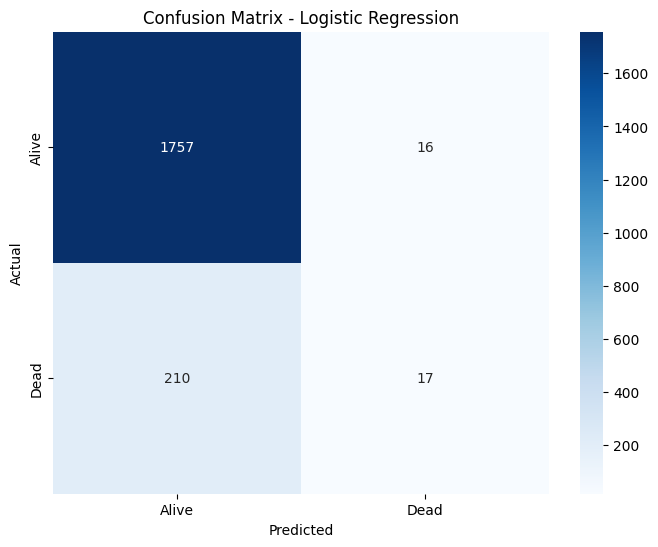

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize and train the Logistic Regression model
# We increase max_iter to ensure convergence on scaled data
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = log_model.predict(X_test)

# Print evaluation metrics
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Alive', 'Dead'], yticklabels=['Alive', 'Dead'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [19]:
%pip install optuna --quiet

#### Hyperparameter Tuning with Optuna

In [20]:
%pip install optuna --quiet
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

def objective(trial):
    # Define the search space
    c_param = trial.suggest_float('C', 1e-4, 1e2, log=True)
    solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear'])

    # Initialize model with current parameters and balanced weights
    model = LogisticRegression(
        C=c_param,
        solver=solver,
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    )

    # Use cross-validation to evaluate the F1 score
    score = cross_val_score(model, X_train, y_train, n_jobs=-1, cv=5, scoring='f1').mean()
    return score

# Create and run the study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print(f"Best F1 score: {study.best_value}")
print(f"Best parameters: {study.best_params}")

[I 2026-07-21 01:18:24,258] A new study created in memory with name: no-name-96d22d4a-81e8-443e-a115-5cf74e407b0d
[I 2026-07-21 01:18:29,041] Trial 0 finished with value: 0.332023138036066 and parameters: {'C': 25.182483356097435, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.332023138036066.
[I 2026-07-21 01:18:29,450] Trial 1 finished with value: 0.3239909015574659 and parameters: {'C': 0.020192935932245488, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.332023138036066.
[I 2026-07-21 01:18:29,690] Trial 2 finished with value: 0.294147783363934 and parameters: {'C': 0.0006318658704611715, 'solver': 'liblinear'}. Best is trial 0 with value: 0.332023138036066.
[I 2026-07-21 01:18:30,231] Trial 3 finished with value: 0.32603512122736394 and parameters: {'C': 0.5260984810523852, 'solver': 'liblinear'}. Best is trial 0 with value: 0.332023138036066.
[I 2026-07-21 01:18:30,748] Trial 4 finished with value: 0.3286727587415436 and parameters: {'C': 9.791828587608519, 'solver': 'liblin

Best F1 score: 0.33243976948633314
Best parameters: {'C': 91.8932092788039, 'solver': 'lbfgs'}



Final Model Classification Report (Optuna Tuned):
              precision    recall  f1-score   support

         0.0       0.95      0.67      0.79      1773
         1.0       0.22      0.71      0.33       227

    accuracy                           0.68      2000
   macro avg       0.58      0.69      0.56      2000
weighted avg       0.86      0.68      0.73      2000



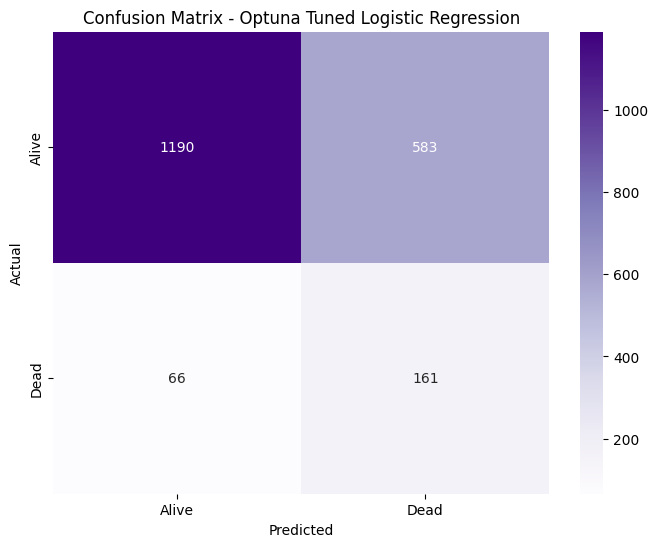

In [21]:
# Train final model with best parameters
best_params = study.best_params
final_log_model = LogisticRegression(**best_params, max_iter=2000, class_weight='balanced', random_state=42)
final_log_model.fit(X_train, y_train)

# Evaluate on test set
y_pred_optuna = final_log_model.predict(X_test)
print("\nFinal Model Classification Report (Optuna Tuned):")
print(classification_report(y_test, y_pred_optuna))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm_optuna = confusion_matrix(y_test, y_pred_optuna)
sns.heatmap(cm_optuna, annot=True, fmt='d', cmap='Purples', xticklabels=['Alive', 'Dead'], yticklabels=['Alive', 'Dead'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Optuna Tuned Logistic Regression')
plt.show()

#### LightGBM Model

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 857, number of negative: 7143
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005067 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1145
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.107125 -> initscore=-2.120450
[LightGBM] [Info] Start training from score -2.120450
Accuracy Score: 0.832

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.87      0.90      1773
         1.0       0.35      0.57      0.44       227

    accuracy                           0.83      2000
   macro avg       0.65      0.72      0.67      2000
weighted avg       0.87      0.83      0.85     

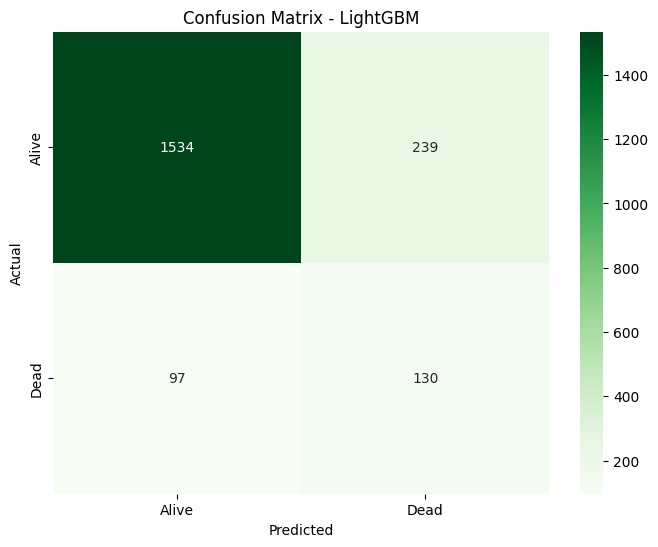

In [22]:
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize the LightGBM Classifier
# We use 'is_unbalance=True' to help handle the class imbalance seen in the previous model
lgb_model = lgb.LGBMClassifier(random_state=42, is_unbalance=True)

# Train the model
lgb_model.fit(X_train, y_train)

# Make predictions
y_pred_lgb = lgb_model.predict(X_test)

# Print evaluation metrics
print("Accuracy Score:", accuracy_score(y_test, y_pred_lgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgb))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Greens', xticklabels=['Alive', 'Dead'], yticklabels=['Alive', 'Dead'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - LightGBM')
plt.show()

#### Hyperparameter Tuning: LightGBM (F1 Optimization with Optuna)

In [23]:
import optuna
import lightgbm as lgb
from sklearn.model_selection import cross_val_score

def objective_lgb(trial):
    param = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'is_unbalance': True,
        'random_state': 42,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
    }

    gbm = lgb.LGBMClassifier(**param)
    # Optimization based on F1 score to balance precision and recall
    score = cross_val_score(gbm, X_train, y_train, n_jobs=-1, cv=5, scoring='f1').mean()
    return score

lgb_study = optuna.create_study(direction='maximize')
lgb_study.optimize(objective_lgb, n_trials=30)

print(f"Best F1 score: {lgb_study.best_value}")
print(f"Best parameters: {lgb_study.best_params}")

[I 2026-07-21 01:18:42,861] A new study created in memory with name: no-name-8a778ed0-2c3b-49f7-81fe-dd2afd5d6845
[I 2026-07-21 01:18:47,469] Trial 0 finished with value: 0.429396385150553 and parameters: {'learning_rate': 0.07065778607405715, 'num_leaves': 106, 'feature_fraction': 0.630560100118133, 'bagging_fraction': 0.6744360650215295, 'bagging_freq': 2, 'min_child_samples': 6}. Best is trial 0 with value: 0.429396385150553.
[I 2026-07-21 01:18:48,655] Trial 1 finished with value: 0.43151975890178046 and parameters: {'learning_rate': 0.05820255601262634, 'num_leaves': 21, 'feature_fraction': 0.5104420650631545, 'bagging_fraction': 0.9601254627590726, 'bagging_freq': 4, 'min_child_samples': 8}. Best is trial 1 with value: 0.43151975890178046.
[I 2026-07-21 01:18:50,168] Trial 2 finished with value: 0.4644897169805642 and parameters: {'learning_rate': 0.13043967328271522, 'num_leaves': 137, 'feature_fraction': 0.6553350367041546, 'bagging_fraction': 0.8749732385503982, 'bagging_freq'

Best F1 score: 0.4644897169805642
Best parameters: {'learning_rate': 0.13043967328271522, 'num_leaves': 137, 'feature_fraction': 0.6553350367041546, 'bagging_fraction': 0.8749732385503982, 'bagging_freq': 3, 'min_child_samples': 99}



Final LightGBM Classification Report (Optuna Tuned):
              precision    recall  f1-score   support

         0.0       0.94      0.90      0.92      1773
         1.0       0.40      0.53      0.45       227

    accuracy                           0.85      2000
   macro avg       0.67      0.71      0.69      2000
weighted avg       0.88      0.85      0.86      2000



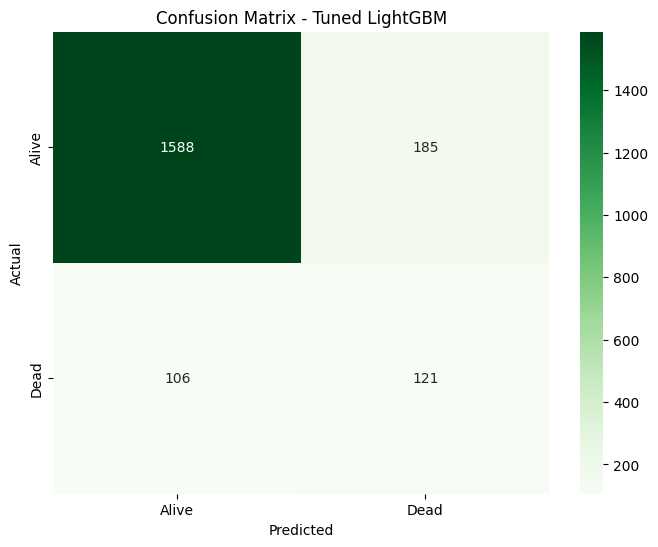

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train final model with the best parameters from Optuna
best_lgb_params = lgb_study.best_params.copy()
best_lgb_params.update({'objective': 'binary', 'metric': 'binary_logloss', 'verbosity': -1, 'is_unbalance': True, 'random_state': 42})

final_lgb_model = lgb.LGBMClassifier(**best_lgb_params)
final_lgb_model.fit(X_train, y_train)

# Evaluate on test set
y_pred_lgb_tuned = final_lgb_model.predict(X_test)

print("\nFinal LightGBM Classification Report (Optuna Tuned):")
print(classification_report(y_test, y_pred_lgb_tuned))

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
cm_lgb_tuned = confusion_matrix(y_test, y_pred_lgb_tuned)
sns.heatmap(cm_lgb_tuned, annot=True, fmt='d', cmap='Greens', xticklabels=['Alive', 'Dead'], yticklabels=['Alive', 'Dead'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned LightGBM')
plt.show()

#### Random Forest Classification Model

Accuracy Score: 0.895

Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      1.00      0.94      1773
         1.0       0.84      0.09      0.17       227

    accuracy                           0.90      2000
   macro avg       0.87      0.55      0.56      2000
weighted avg       0.89      0.90      0.86      2000



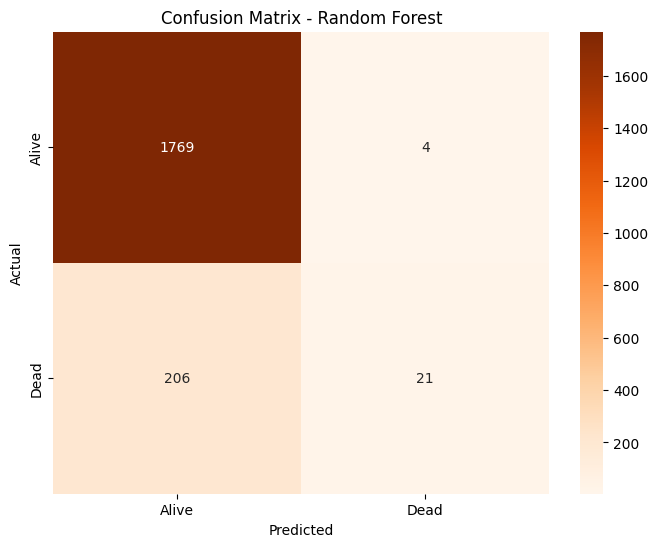

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize the Random Forest Classifier
# Using class_weight='balanced' to handle the imbalanced nature of the dataset
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Print evaluation metrics
print("Accuracy Score:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', xticklabels=['Alive', 'Dead'], yticklabels=['Alive', 'Dead'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

#### Hyperparameter Tuning: Random Forest (F1 Optimization with Optuna)

In [26]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def objective_rf(trial):
    # Define the search space for Random Forest
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1
    }

    rf = RandomForestClassifier(**params)
    # Optimize based on F1 score
    score = cross_val_score(rf, X_train, y_train, n_jobs=-1, cv=5, scoring='f1').mean()
    return score

rf_study = optuna.create_study(direction='maximize')
rf_study.optimize(objective_rf, n_trials=20)

print(f"Best F1 score: {rf_study.best_value}")
print(f"Best parameters: {rf_study.best_params}")

[I 2026-07-21 01:19:45,861] A new study created in memory with name: no-name-53fa43fb-c3e8-4c23-a4ec-883be5e66202
[I 2026-07-21 01:19:52,180] Trial 0 finished with value: 0.4460939002422215 and parameters: {'n_estimators': 155, 'max_depth': 17, 'min_samples_split': 17, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.4460939002422215.
[I 2026-07-21 01:20:04,648] Trial 1 finished with value: 0.45590275377966566 and parameters: {'n_estimators': 278, 'max_depth': 17, 'min_samples_split': 15, 'min_samples_leaf': 8}. Best is trial 1 with value: 0.45590275377966566.
[I 2026-07-21 01:20:10,046] Trial 2 finished with value: 0.356057215320601 and parameters: {'n_estimators': 209, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.45590275377966566.
[I 2026-07-21 01:20:14,149] Trial 3 finished with value: 0.4229174693142438 and parameters: {'n_estimators': 69, 'max_depth': 11, 'min_samples_split': 11, 'min_samples_leaf': 1}. Best is trial 1 with va

Best F1 score: 0.4588745196954228
Best parameters: {'n_estimators': 181, 'max_depth': 25, 'min_samples_split': 17, 'min_samples_leaf': 4}



Final Random Forest Classification Report (Optuna Tuned):
              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93      1773
         1.0       0.44      0.45      0.45       227

    accuracy                           0.87      2000
   macro avg       0.69      0.69      0.69      2000
weighted avg       0.87      0.87      0.87      2000



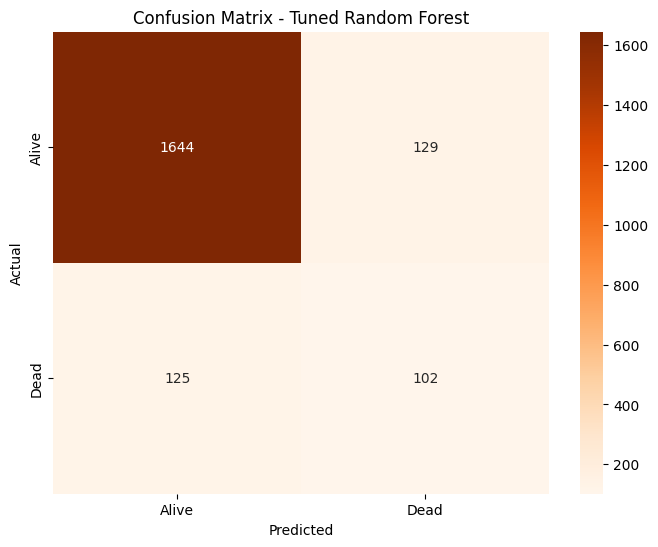

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train final model with the best parameters
best_rf_params = rf_study.best_params.copy()
best_rf_params.update({'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1})

final_rf_model = RandomForestClassifier(**best_rf_params)
final_rf_model.fit(X_train, y_train)

# Evaluate on test set
y_pred_rf_tuned = final_rf_model.predict(X_test)

print("\nFinal Random Forest Classification Report (Optuna Tuned):")
print(classification_report(y_test, y_pred_rf_tuned))

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)
sns.heatmap(cm_rf_tuned, annot=True, fmt='d', cmap='Oranges', xticklabels=['Alive', 'Dead'], yticklabels=['Alive', 'Dead'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned Random Forest')
plt.show()

#### Permutation Feature Importance (Random Forest & LightGBM)

Permutation importance is model-agnostic and more reliable than impurity/split-based
importance because it measures the drop in a chosen metric when the values of a single
feature are randomly shuffled on the held-out test set.

Top 15 features - Random Forest (permutation importance, f1):
                 feature  importance_mean  importance_std
          length_of_stay         0.109000        0.021254
        age_at_admission         0.055078        0.018131
               pregnancy         0.042664        0.004320
             respiratory         0.032757        0.018548
              infectious         0.018773        0.005671
                    misc         0.016871        0.005927
admission_type_EMERGENCY         0.015330        0.007813
           num_diagnoses         0.014163        0.013581
          avg_heart_rate         0.012295        0.010683
           num_icu_stays         0.011303        0.004534
 ethnicity_OTHER/UNKNOWN         0.011048        0.005977
                  mental         0.010228        0.006931
   marital_status_SINGLE         0.010101        0.006036
               endocrine         0.008868        0.005703
           genitourinary         0.007776        0.003948

Top 15 fe

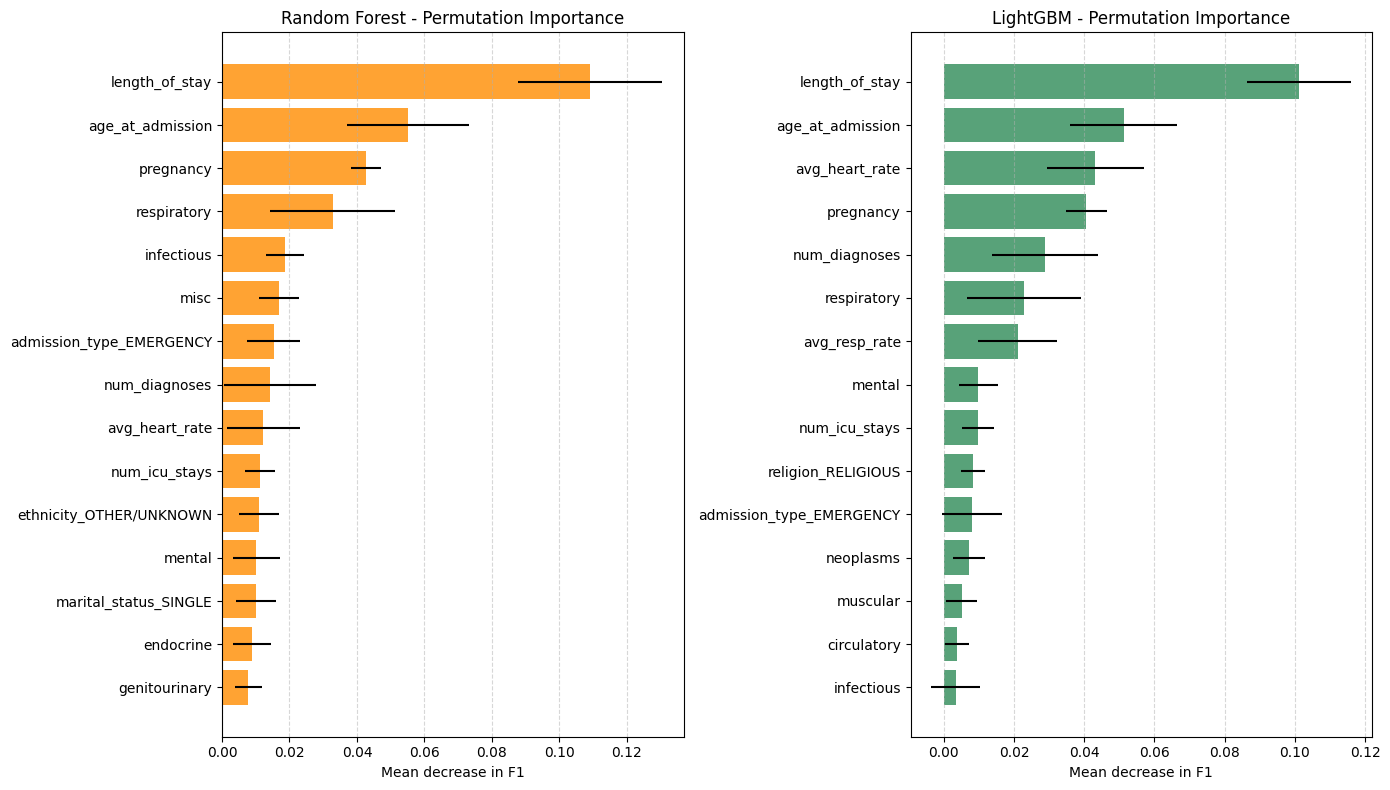

In [28]:
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def compute_permutation_importance(model, X_eval, y_eval, scoring="f1",
                                   n_repeats=10, random_state=42, n_jobs=-1):
    """Compute permutation importance and return a sorted DataFrame."""
    result = permutation_importance(
        model, X_eval, y_eval,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=n_jobs,
    )
    imp_df = pd.DataFrame({
        "feature": X_eval.columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std,
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)
    return imp_df, result


# Compute for both tuned models on the test set
rf_importance_df, rf_perm = compute_permutation_importance(
    final_rf_model, X_test, y_test, scoring="f1"
)
lgb_importance_df, lgb_perm = compute_permutation_importance(
    final_lgb_model, X_test, y_test, scoring="f1"
)

print("Top 15 features - Random Forest (permutation importance, f1):")
print(rf_importance_df.head(15).to_string(index=False))
print("\nTop 15 features - LightGBM (permutation importance, f1):")
print(lgb_importance_df.head(15).to_string(index=False))


# Plot side-by-side top-N features
def plot_top_importance(imp_df, title, ax, top_n=15, color="steelblue"):
    top = imp_df.head(top_n).iloc[::-1]  # reverse for horizontal bar
    ax.barh(top["feature"], top["importance_mean"],
            xerr=top["importance_std"], color=color, alpha=0.8)
    ax.set_xlabel("Mean decrease in F1")
    ax.set_title(title)
    ax.grid(axis="x", linestyle="--", alpha=0.5)


fig, axes = plt.subplots(1, 2, figsize=(14, 8))
plot_top_importance(rf_importance_df, "Random Forest - Permutation Importance",
                    axes[0], color="darkorange")
plot_top_importance(lgb_importance_df, "LightGBM - Permutation Importance",
                    axes[1], color="seagreen")
plt.tight_layout()
plt.show()

#### Tuned Models - Confusion Matrix Comparison

Side-by-side confusion matrices for the three Optuna-tuned models on the test set.

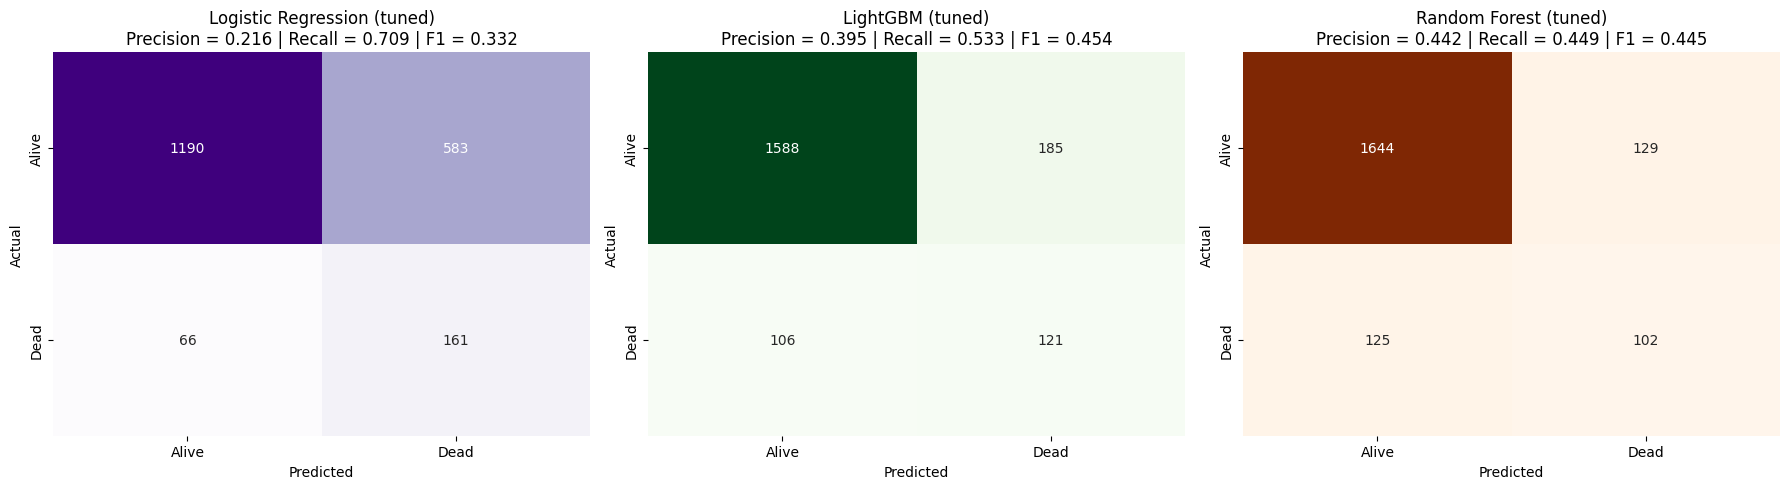


Tuned models - precision / recall / F1 (positive class = Dead):
                      model  precision   recall       f1
Logistic Regression (tuned)   0.216398 0.709251 0.331617
           LightGBM (tuned)   0.395425 0.533040 0.454034
      Random Forest (tuned)   0.441558 0.449339 0.445415


In [30]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

# Collect tuned model predictions (already computed above)
tuned_results = [
    ("Logistic Regression (tuned)", y_pred_optuna,    "Purples"),
    ("LightGBM (tuned)",            y_pred_lgb_tuned, "Greens"),
    ("Random Forest (tuned)",       y_pred_rf_tuned,  "Oranges"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['Alive', 'Dead']

for ax, (name, y_pred, cmap) in zip(axes, tuned_results):
    cm        = confusion_matrix(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred, zero_division=0)

    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labels, yticklabels=labels, cbar=False, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f"{name}\nPrecision = {precision:.3f} | Recall = {recall:.3f} | F1 = {f1:.3f}")

plt.tight_layout()
plt.show()

# Also print a compact summary table
import pandas as pd
summary = pd.DataFrame([
    {
        "model":     name,
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall":    recall_score(y_test, y_pred, zero_division=0),
        "f1":        f1_score(y_test, y_pred),
    }
    for name, y_pred, _ in tuned_results
])
print("\nTuned models - precision / recall / F1 (positive class = Dead):")
print(summary.to_string(index=False))